# NASDAQ-100 RecSys — 1.2-B Evaluation & Practical Usage

This notebook answers two questions:
1. **Are the models any good?** — formal quality evaluation
2. **How do I actually use them?** — practical demonstrations

---
**Sections:**
1. Setup & load everything
2. Quality evaluation (RMSE, IC, NDCG, Hit Rate, Sharpe)
3. Ablation study — which components matter?
4. Practical usage demos
   - 4.1 Daily stock screener
   - 4.2 Portfolio simulator
   - 4.3 'Why this stock?' — model explainability
   - 4.4 Regime analysis — when does each model fail?
5. Final summary table

---
## 1. Setup & Load Everything

In [7]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

ARTEFACT   = './artefacts'
MODEL_PATH = './models'
TOP_N      = 10   # number of stocks recommended per day

In [8]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_train = pd.read_parquet(f'{ARTEFACT}/df_train.parquet')
df_val   = pd.read_parquet(f'{ARTEFACT}/df_val.parquet')
df_test  = pd.read_parquet(f'{ARTEFACT}/df_test.parquet')

X_train = np.load(f'{ARTEFACT}/X_train.npy')
X_val   = np.load(f'{ARTEFACT}/X_val.npy')
X_test  = np.load(f'{ARTEFACT}/X_test.npy')

y_test_reg = np.load(f'{ARTEFACT}/y_test_reg.npy')
y_val_reg  = np.load(f'{ARTEFACT}/y_val_reg.npy')

FEATURE_COLS = joblib.load(f'{ARTEFACT}/feature_cols.pkl')
scaler       = joblib.load(f'{ARTEFACT}/robust_scaler.pkl')

print(f'Test set : {df_test.shape}  |  {df_test["Date"].min().date()} → {df_test["Date"].max().date()}')
print(f'Tickers  : {df_test["Ticker"].nunique()}')

Test set : (93472, 54)  |  2022-04-20 → 2026-02-10
Tickers  : 98


In [9]:
# ── Class definitions — MUST run before joblib.load() ────────────────────────
# joblib serialises objects by reference to their class name.
# If the class does not exist in __main__ when load() is called,
# Python raises: AttributeError: module '__main__' has no attribute 'ClassName'
# Solution: redefine all three model classes here before unpickling.

import lightgbm as lgb
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge


class MomentumBaseline:
    def __init__(self, momentum_col='Momentum_21d'):
        self.momentum_col = momentum_col

    def predict(self, df):
        return df[self.momentum_col].values

    def recommend(self, df, date, top_n=10):
        day = df[df['Date'] == date].copy()
        day['score'] = self.predict(day)
        return day.nlargest(top_n, 'score')[['Ticker', 'score']].reset_index(drop=True)


class SVDCollaborativeFilter:
    def __init__(self, n_components=30, random_state=42):
        self.n_components = n_components
        self.svd          = TruncatedSVD(n_components=n_components,
                                         random_state=random_state)
        self.tickers_     = None
        self.R_mean_      = None

    def _build_matrix(self, df):
        return df.pivot_table(index='Date', columns='Ticker',
                              values='Log_Return').fillna(0)

    def fit(self, df_train):
        R             = self._build_matrix(df_train)
        self.tickers_ = R.columns.tolist()
        self.R_mean_  = R.mean(axis=0)
        self.svd.fit(R - self.R_mean_)
        return self

    def predict(self, df):
        R      = self._build_matrix(df)
        R      = R.reindex(columns=self.tickers_, fill_value=0)
        coords = self.svd.transform(R - self.R_mean_)
        R_hat  = pd.DataFrame(
            coords @ self.svd.components_ + self.R_mean_.values,
            index=R.index, columns=self.tickers_
        )
        R_long = R_hat.stack().reset_index()
        R_long.columns = ['Date', 'Ticker', 'pred']
        merged = df[['Date', 'Ticker']].merge(R_long, on=['Date', 'Ticker'], how='left')
        return merged['pred'].fillna(0).values


class ContentBasedFilter:
    def __init__(self, n_neighbors=10, alpha_blend=0.5, ridge_alpha=10.0):
        self.n_neighbors      = n_neighbors
        self.alpha_blend      = alpha_blend
        self.ridge            = Ridge(alpha=ridge_alpha)
        self.sim_matrix_      = None
        self.tickers_         = None
        self.ticker_mean_ret_ = None

    def fit(self, df_train, X_train, y_train, item_sim_cosine):
        self.ridge.fit(X_train, y_train)
        self.tickers_         = df_train['Ticker'].unique().tolist()
        common                = [t for t in self.tickers_ if t in item_sim_cosine.index]
        self.sim_matrix_      = item_sim_cosine.loc[common, common]
        self.ticker_mean_ret_ = df_train.groupby('Ticker')['Target_Ret_5d'].mean()
        return self

    def predict(self, df, X):
        return self.ridge.predict(X)


print('Class definitions ready — safe to load pickled models.')

Class definitions ready — safe to load pickled models.


In [10]:
# ── Load models (auto-detects LightGBM .txt vs sklearn .pkl) ────────────────
import os

momentum_model = joblib.load(f'{MODEL_PATH}/model0_momentum.pkl')
svd_cf         = joblib.load(f'{MODEL_PATH}/model1_svd_cf.pkl')
cb_model       = joblib.load(f'{MODEL_PATH}/model2_content_cb.pkl')
AUG_COLS       = joblib.load(f'{MODEL_PATH}/aug_feature_cols.pkl')

# Hybrid model — saved as .txt (LightGBM native) or .pkl (sklearn fallback)
lgbm_txt = f'{MODEL_PATH}/model3_hybrid_lgbm.txt'
lgbm_pkl = f'{MODEL_PATH}/model3_hybrid_gbm.pkl'

if os.path.exists(lgbm_txt):
    lgb_model      = lgb.Booster(model_file=lgbm_txt)
    LGBM_AVAILABLE = True
    print('Loaded LightGBM native model (.txt)')
elif os.path.exists(lgbm_pkl):
    lgb_model      = joblib.load(lgbm_pkl)
    LGBM_AVAILABLE = False
    print('Loaded sklearn HistGBM fallback model (.pkl)')
else:
    raise FileNotFoundError(
        f'No hybrid model found. Expected:\n  {lgbm_txt}\n  {lgbm_pkl}'
    )

print('All models loaded.')
print(f'  LGBM_AVAILABLE = {LGBM_AVAILABLE}')

Loaded LightGBM native model (.txt)
All models loaded.
  LGBM_AVAILABLE = True


In [11]:
# ── Safe predict helper — works for both LightGBM and sklearn fallback ───────
def model_predict(X):
    if LGBM_AVAILABLE:
        return lgb_model.predict(X, num_iteration=lgb_model.best_iteration)
    return lgb_model.predict(X)

print('model_predict() helper ready.')

model_predict() helper ready.


In [12]:
# ── Rebuild augmented feature matrices ───────────────────────────────────────
def build_augmented(df, X, svd_model, cb_model_obj, momentum_col='Momentum_21d'):
    svd_preds   = svd_model.predict(df)
    mom_preds   = df[momentum_col].values
    ridge_preds = cb_model_obj.ridge.predict(X)
    return np.hstack([X, np.column_stack([svd_preds, mom_preds, ridge_preds])])

X_val_aug  = build_augmented(df_val,  X_val,  svd_cf, cb_model)
X_test_aug = build_augmented(df_test, X_test, svd_cf, cb_model)

# ── All predictions in one dict for easy looping ─────────────────────────────
PREDS = {
    'Momentum' : {'val': momentum_model.predict(df_val),
                  'test': momentum_model.predict(df_test)},
    'SVD CF'   : {'val': svd_cf.predict(df_val),
                  'test': svd_cf.predict(df_test)},
    'Content'  : {'val': cb_model.ridge.predict(X_val),
                  'test': cb_model.ridge.predict(X_test)},
    'Hybrid'   : {'val': model_predict(X_val_aug),
                  'test': model_predict(X_test_aug)},
}
print('Predictions built for all models on val and test.')

Predictions built for all models on val and test.


---
## 2. Quality Evaluation

We measure quality from three angles:

| Metric | What it measures | Good value |
|---|---|---|
| **RMSE / MAE** | Regression accuracy of the predicted return | As low as possible |
| **IC (Information Coefficient)** | Spearman rank correlation between predicted and actual returns, averaged per day | IC > 0.05 is useful; > 0.10 is strong |
| **Hit Rate @ N** | % of top-N recommendations that have positive returns | > 0.55 beats random |
| **NDCG @ N** | Ranking quality — best stocks ranked highest | Higher = better; 1.0 = perfect |
| **Sharpe Ratio** | Risk-adjusted return of following recommendations | > 1.0 is good; > 2.0 is excellent |

In [13]:
# ── 2.1  Metric implementations ───────────────────────────────────────────────

def mean_ic(df, preds, target='Target_Ret_5d'):
    """Mean daily Spearman IC."""
    df = df.assign(pred=preds)
    daily = df.groupby('Date').apply(
        lambda g: spearmanr(g['pred'], g[target])[0]
    )
    return daily.mean(), daily.std(), daily

def hit_rate(df, preds, n=TOP_N, target='Target_Ret_5d'):
    """Fraction of top-N recommendations with positive return."""
    df = df.assign(pred=preds)
    return df.groupby('Date').apply(
        lambda g: (g.nlargest(n, 'pred')[target] > 0).mean()
    ).mean()

def ndcg_at_k(df, preds, k=TOP_N, target='Target_Ret_5d'):
    """NDCG@K — measures whether the best stocks are ranked highest."""
    def _ndcg(g):
        g = g.sort_values('pred', ascending=False)
        # Relevance = rank of actual return (higher return = more relevant)
        g['rel'] = g[target].rank(ascending=True)
        topk  = g.head(k)
        ideal = g.nlargest(k, target)
        dcg   = (topk['rel'].values / np.log2(np.arange(2, k + 2))).sum()
        idcg  = (ideal['rel'].values / np.log2(np.arange(2, k + 2))).sum()
        return dcg / idcg if idcg > 0 else 0.0
    return df.assign(pred=preds).groupby('Date').apply(_ndcg).mean()

def sharpe_ratio(df, preds, n=TOP_N, target='Target_Ret_5d', periods=252):
    """Annualised Sharpe of equal-weight top-N portfolio."""
    df = df.assign(pred=preds)
    daily = df.groupby('Date').apply(
        lambda g: g.nlargest(n, 'pred')[target].mean()
    )
    return (daily.mean() / (daily.std() + 1e-10)) * np.sqrt(periods)

def max_drawdown(returns_series):
    """Maximum drawdown of a cumulative return series."""
    cum = returns_series.cumsum()
    roll_max = cum.cummax()
    drawdown = cum - roll_max
    return drawdown.min()

print('Metric functions ready.')

Metric functions ready.


In [14]:
# ── 2.2  Full evaluation table ────────────────────────────────────────────────
rows = []
for split, df_s in [('Val', df_val), ('Test', df_test)]:
    y_true = df_s['Target_Ret_5d'].values
    for model_name, pred_dict in PREDS.items():
        preds = pred_dict[split.lower()]
        ic_mean, ic_std, _ = mean_ic(df_s, preds)
        rows.append({
            'Split'      : split,
            'Model'      : model_name,
            'RMSE'       : np.sqrt(mean_squared_error(y_true, preds)),
            'MAE'        : mean_absolute_error(y_true, preds),
            'IC'         : ic_mean,
            'IC_std'     : ic_std,
            'ICIR'       : ic_mean / (ic_std + 1e-10),   # IC Information Ratio
            f'HR@{TOP_N}': hit_rate(df_s, preds, n=TOP_N),
            f'NDCG@{TOP_N}': ndcg_at_k(df_s, preds, k=TOP_N),
            'Sharpe'     : sharpe_ratio(df_s, preds, n=TOP_N),
        })

results_df = pd.DataFrame(rows)
print('=== EVALUATION RESULTS ===')
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

=== EVALUATION RESULTS ===
Split    Model   RMSE    MAE      IC  IC_std    ICIR  HR@10  NDCG@10  Sharpe
  Val Momentum 0.1118 0.0818 -0.0246  0.2216 -0.1109 0.5366   0.5136  0.9952
  Val   SVD CF 0.0532 0.0382 -0.0131  0.1997 -0.0655 0.5491   0.5236  1.6068
  Val  Content 0.0496 0.0356  0.0260  0.1926  0.1350 0.5601   0.5344  2.1408
  Val   Hybrid 0.9753 0.8183  0.0070  0.2231  0.0316 0.5612   0.5306  2.1684
 Test Momentum 0.1173 0.0858  0.0041  0.2249  0.0182 0.5348   0.5286  1.5420
 Test   SVD CF 0.0549 0.0397 -0.0031  0.1814 -0.0169 0.5302   0.5273  1.2090
 Test  Content 0.0521 0.0375  0.0179  0.1967  0.0910 0.5350   0.5330  1.5967
 Test   Hybrid 0.9334 0.7749 -0.0051  0.2382 -0.0216 0.5290   0.5201  0.6962


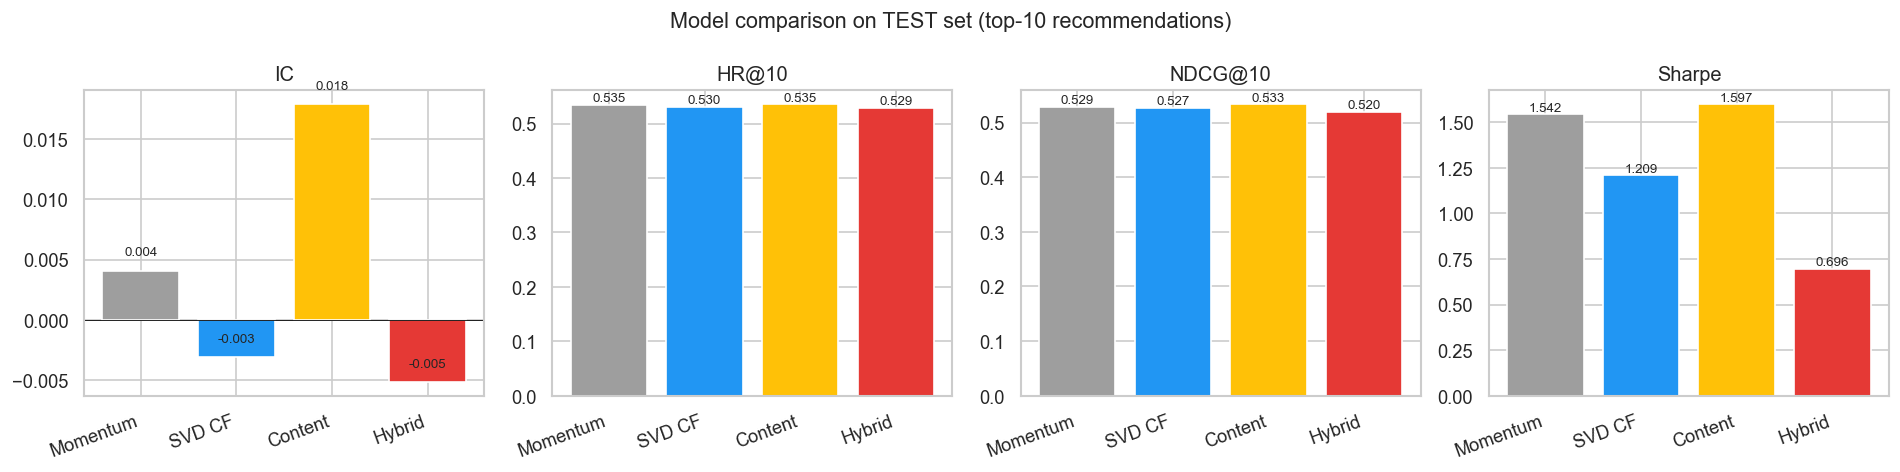


How to read these metrics:
  IC       > 0.05 = useful signal; > 0.10 = strong signal
  Hit Rate > 0.55 = better than random (random ≈ 0.50)
  NDCG     > market average = model ranks well
  Sharpe   > 1.0  = good; > 2.0 = excellent risk-adjusted return



In [15]:
# ── 2.3  Visual comparison ────────────────────────────────────────────────────
test_results = results_df[results_df['Split'] == 'Test'].set_index('Model')

metrics_to_plot = ['IC', f'HR@{TOP_N}', f'NDCG@{TOP_N}', 'Sharpe']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
palette = ['#9E9E9E', '#2196F3', '#FFC107', '#E53935']

for ax, metric in zip(axes, metrics_to_plot):
    vals = test_results[metric]
    bars = ax.bar(vals.index, vals.values, color=palette)
    ax.set_title(metric)
    ax.set_xticklabels(vals.index, rotation=20, ha='right')
    ax.axhline(0, color='black', lw=0.5)
    # Annotate values
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Model comparison on TEST set (top-{TOP_N} recommendations)', fontsize=13)
plt.tight_layout()
plt.show()

print("""
How to read these metrics:
  IC       > 0.05 = useful signal; > 0.10 = strong signal
  Hit Rate > 0.55 = better than random (random ≈ 0.50)
  NDCG     > market average = model ranks well
  Sharpe   > 1.0  = good; > 2.0 = excellent risk-adjusted return
""")

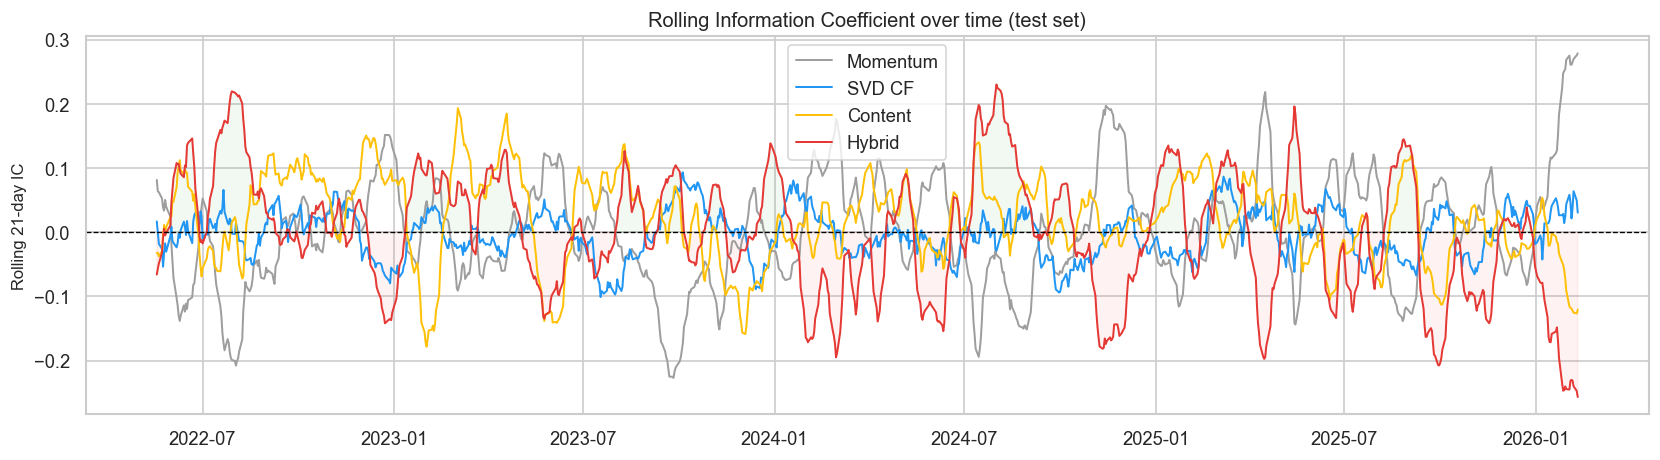


Interpretation:
  - Periods above 0 = the model correctly ranked stocks (winners above losers).
  - Periods below 0 = the model's ranking was inverted — this can happen during
    sharp regime changes (rate shock, black swan event).
  - A model with consistently positive IC, even if small, is valuable.
  - Sharp IC drops on specific dates are worth investigating — they often
    correspond to macro announcements or sector rotations the model didn't expect.



In [16]:
# ── 2.4  Rolling IC over time — does the model stay consistent? ───────────────
fig, ax = plt.subplots(figsize=(14, 4))
palette = {'Momentum':'#9E9E9E', 'SVD CF':'#2196F3',
           'Content':'#FFC107', 'Hybrid':'#E53935'}

for model_name, color in palette.items():
    _, _, daily_ic = mean_ic(df_test, PREDS[model_name]['test'])
    rolling_ic = daily_ic.rolling(21).mean()   # 21-day smoothing
    ax.plot(rolling_ic.index, rolling_ic.values,
            lw=1.2, label=model_name, color=color)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.fill_between(rolling_ic.index, 0, rolling_ic.values,
                where=rolling_ic.values > 0, alpha=0.05, color='green')
ax.fill_between(rolling_ic.index, 0, rolling_ic.values,
                where=rolling_ic.values < 0, alpha=0.05, color='red')
ax.set_ylabel('Rolling 21-day IC')
ax.set_title('Rolling Information Coefficient over time (test set)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Periods above 0 = the model correctly ranked stocks (winners above losers).
  - Periods below 0 = the model's ranking was inverted — this can happen during
    sharp regime changes (rate shock, black swan event).
  - A model with consistently positive IC, even if small, is valuable.
  - Sharp IC drops on specific dates are worth investigating — they often
    correspond to macro announcements or sector rotations the model didn't expect.
""")

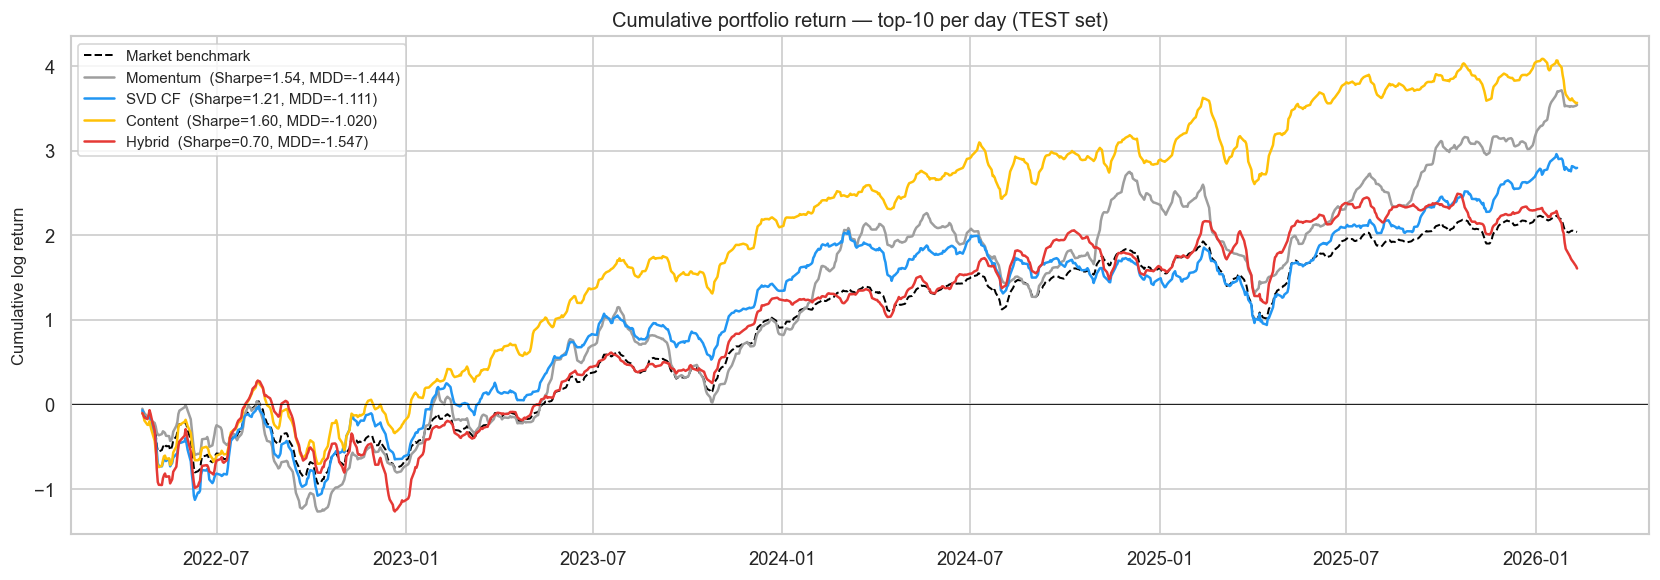

In [17]:
# ── 2.5  Cumulative portfolio return vs market benchmark ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Market benchmark: equal-weight all tickers every day
mkt = df_test.groupby('Date')['Target_Ret_5d'].mean().cumsum()
ax.plot(mkt.index, mkt.values, color='black', lw=1.2,
        linestyle='--', label='Market benchmark')

palette = {'Momentum':'#9E9E9E', 'SVD CF':'#2196F3',
           'Content':'#FFC107', 'Hybrid':'#E53935'}

for model_name, color in palette.items():
    preds = PREDS[model_name]['test']
    df_s  = df_test.assign(pred=preds)
    daily = df_s.groupby('Date').apply(
        lambda g: g.nlargest(TOP_N, 'pred')['Target_Ret_5d'].mean()
    )
    cum = daily.cumsum()
    sr  = sharpe_ratio(df_test, preds)
    md  = max_drawdown(daily)
    ax.plot(cum.index, cum.values, lw=1.5, color=color,
            label=f'{model_name}  (Sharpe={sr:.2f}, MDD={md:.3f})')

ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Cumulative log return')
ax.set_title(f'Cumulative portfolio return — top-{TOP_N} per day (TEST set)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Ablation Study — Which Components Matter?

An ablation study removes one component at a time to see how much it contributes.  
This answers: **is the hybrid genuinely better, or just lucky?**

In [18]:
# We test the hybrid ranker with each meta-feature zeroed out.
# If removing a feature hurts performance, that feature is contributing.

def ablate_feature(X_aug, col_name, aug_cols):
    """Return a copy of X_aug with one column set to its mean (neutered)."""
    X_copy = X_aug.copy()
    idx = aug_cols.index(col_name)
    X_copy[:, idx] = X_copy[:, idx].mean()   # replace with constant → no signal
    return X_copy

ablation_cols = ['SVD_score', 'Momentum_score', 'Ridge_score']
ablation_rows = []

# Baseline (full hybrid)
base_ic, _, _ = mean_ic(df_test, PREDS['Hybrid']['test'])
base_hr       = hit_rate(df_test, PREDS['Hybrid']['test'])
base_sharpe   = sharpe_ratio(df_test, PREDS['Hybrid']['test'])
ablation_rows.append({'Removed': 'None (full model)',
                      'IC': base_ic, 'HR': base_hr, 'Sharpe': base_sharpe})

for col in ablation_cols:
    X_ablated = ablate_feature(X_test_aug, col, AUG_COLS)
    preds_ab  = model_predict(X_ablated)
    ic_ab, _, _ = mean_ic(df_test, preds_ab)
    hr_ab       = hit_rate(df_test, preds_ab)
    sh_ab       = sharpe_ratio(df_test, preds_ab)
    ablation_rows.append({'Removed': col, 'IC': ic_ab,
                          'HR': hr_ab, 'Sharpe': sh_ab})

abl_df = pd.DataFrame(ablation_rows)
abl_df['IC_drop']     = abl_df['IC']     - base_ic
abl_df['Sharpe_drop'] = abl_df['Sharpe'] - base_sharpe

print('=== ABLATION STUDY (TEST SET) ===')
print(abl_df.to_string(index=False, float_format='{:.4f}'.format))
print("""
Interpretation:
  - A large negative IC_drop when a component is removed means that
    component was genuinely contributing signal.
  - A near-zero drop means the hybrid learned to ignore that signal —
    it may be redundant given the other features.
  - If removing SVD_score barely changes performance, collaborative
    filtering adds little over the content-based features alone.
""")

=== ABLATION STUDY (TEST SET) ===
          Removed      IC     HR  Sharpe  IC_drop  Sharpe_drop
None (full model) -0.0051 0.5290  0.6962   0.0000       0.0000
        SVD_score -0.0052 0.5293  0.6428  -0.0000      -0.0534
   Momentum_score -0.0053 0.5296  0.7150  -0.0002       0.0188
      Ridge_score -0.0055 0.5286  0.6280  -0.0003      -0.0682

Interpretation:
  - A large negative IC_drop when a component is removed means that
    component was genuinely contributing signal.
  - A near-zero drop means the hybrid learned to ignore that signal —
    it may be redundant given the other features.
  - If removing SVD_score barely changes performance, collaborative
    filtering adds little over the content-based features alone.



---
## 4. Practical Usage Demos

These cells show exactly how you would use the models in practice.

### 4.1 Daily Stock Screener
**Use case:** Every morning, you want to know which 10 stocks the model thinks will outperform over the next week.

In [19]:
def daily_screener(date_str, model='hybrid', top_n=10, bottom_n=5):
    """
    Given a date, print:
      - Top-N stocks to BUY (predicted to outperform)
      - Bottom-N stocks to AVOID (predicted to underperform)
      - Each stock's key stats so you can sanity-check the recommendation
    """
    date = pd.Timestamp(date_str)

    # Combine val + test so we can look up any date
    df_all = pd.concat([df_val, df_test])
    X_base = np.vstack([X_val, X_test])
    X_aug  = np.vstack([X_val_aug, X_test_aug])

    mask   = df_all['Date'] == date
    df_day = df_all[mask].copy()
    X_d_base = X_base[mask.values]
    X_d_aug  = X_aug[mask.values]

    if len(df_day) == 0:
        print(f'No data for {date_str}. Try a weekday that falls within the dataset.')
        return

    # Get scores from chosen model
    if model == 'hybrid':
        scores = model_predict(X_d_aug)
    elif model == 'content':
        scores = cb_model.ridge.predict(X_d_base)
    elif model == 'svd':
        scores = svd_cf.predict(df_day)
    else:  # momentum
        scores = df_day['Momentum_21d'].values

    df_day = df_day.assign(Score=scores)

    # Select display columns
    display_cols = ['Ticker', 'Score', 'Momentum_21d', 'RSI_14',
                    'ATR_14_Pct', 'Target_Ret_5d']
    display_cols = [c for c in display_cols if c in df_day.columns]

    top  = df_day.nlargest(top_n, 'Score')[display_cols].reset_index(drop=True)
    bot  = df_day.nsmallest(bottom_n, 'Score')[display_cols].reset_index(drop=True)

    top.index  = range(1, top_n + 1)
    bot.index  = range(1, bottom_n + 1)

    print(f'\n══ DAILY SCREENER  {date_str}  [{model.upper()} model] ══')
    print(f'\n▲ TOP {top_n} — BUY candidates (predicted to outperform next 5 days)')
    print(top.rename(columns={'Target_Ret_5d': 'Actual_5d_Ret'}).to_string())
    print(f'\n▼ BOTTOM {bottom_n} — AVOID (predicted to underperform)')
    print(bot.rename(columns={'Target_Ret_5d': 'Actual_5d_Ret'}).to_string())
    print()
    print('  Score       = model confidence (higher = stronger buy signal)')
    print('  Momentum_21d = 21-day cumulative return (past trend)')
    print('  RSI_14       = Relative Strength Index (>70 overbought, <30 oversold)')
    print('  ATR_14_Pct   = Average True Range % (daily volatility)')
    print('  Actual_5d_Ret = what actually happened (for backtesting only)')


# ── Try it on a few dates ─────────────────────────────────────────────────────
test_dates = df_test['Date'].unique()
daily_screener(str(test_dates[30].date()), model='hybrid')
daily_screener(str(test_dates[30].date()), model='momentum')


══ DAILY SCREENER  2022-06-02  [HYBRID model] ══

▲ TOP 10 — BUY candidates (predicted to outperform next 5 days)
   Ticker     Score  Momentum_21d     RSI_14  ATR_14_Pct  Actual_5d_Ret
1    COIN  1.287363     -0.243815  60.542251    0.117216      -0.146504
2     APP  1.007068     -0.121863  57.070876    0.095430      -0.016000
3    TEAM  0.923755     -0.157917  61.519727    0.072529      -0.002852
4     KDP  0.686066     -0.051591  37.166666    0.024490       0.002008
5     WBD  0.679574     -0.055991  54.669464    0.053968      -0.141180
6    DXCM  0.642735     -0.212896  50.087566    0.073756      -0.050645
7    PYPL  0.642496     -0.016809  70.921562    0.047077      -0.048841
8    WDAY  0.613122     -0.181696  48.331988    0.055076      -0.096651
9    ISRG  0.574352     -0.046858  60.280869    0.038668      -0.079005
10   NFLX  0.529744      0.025680  68.554216    0.049418      -0.061844

▼ BOTTOM 5 — AVOID (predicted to underperform)
  Ticker     Score  Momentum_21d     RSI_14  

### 4.2 Portfolio Simulator
**Use case:** You follow the model's top-N recommendations every day. How would your portfolio have performed?

In [20]:
def portfolio_simulator(df, preds, top_n=10, cost_per_trade=0.001):
    """
    Simulates holding the top-N stocks each day.
    Returns a daily performance DataFrame.

    Parameters
    ----------
    cost_per_trade : float
        One-way transaction cost as fraction of trade value.
        0.001 = 10bps (realistic for liquid large-cap stocks).
    """
    df = df.assign(pred=preds).sort_values('Date')
    prev_portfolio = set()
    records = []

    for date, grp in df.groupby('Date'):
        top         = set(grp.nlargest(top_n, 'pred')['Ticker'])
        gross_ret   = grp[grp['Ticker'].isin(top)]['Target_Ret_5d'].mean()

        # Turnover = fraction of portfolio that changed
        if prev_portfolio:
            turnover   = len(top.symmetric_difference(prev_portfolio)) / top_n
        else:
            turnover   = 1.0

        cost        = turnover * cost_per_trade
        net_ret     = gross_ret - cost
        records.append({
            'Date'      : date,
            'Portfolio' : list(top),
            'Gross_Ret' : gross_ret,
            'Cost'      : cost,
            'Net_Ret'   : net_ret,
            'Turnover'  : turnover,
        })
        prev_portfolio = top

    return pd.DataFrame(records).set_index('Date')


# Run simulation for all models
sim_results = {}
for model_name, pred_dict in PREDS.items():
    sim_results[model_name] = portfolio_simulator(
        df_test, pred_dict['test'], top_n=TOP_N
    )

# ── Performance summary ───────────────────────────────────────────────────────
print(f'{'Model':<15} {'Total Return':>13} {'Ann. Return':>12} '
      f'{'Sharpe':>8} {'Max DD':>8} {'Avg Turnover':>14}')
print('-' * 75)

mkt_ret = df_test.groupby('Date')['Target_Ret_5d'].mean()

for model_name, sim in sim_results.items():
    daily   = sim['Net_Ret']
    total   = daily.sum()
    ann     = daily.mean() * 252
    sr      = (daily.mean() / (daily.std() + 1e-10)) * np.sqrt(252)
    mdd     = max_drawdown(daily)
    turnover = sim['Turnover'].mean()
    print(f'{model_name:<15} {total:>13.4f} {ann:>12.4f} '
          f'{sr:>8.3f} {mdd:>8.4f} {turnover:>14.3f}')

# Market benchmark
print(f"{'Market (EW)':<15} {mkt_ret.sum():>13.4f} "
      f"{mkt_ret.mean()*252:>12.4f} "
      f"{(mkt_ret.mean()/(mkt_ret.std()+1e-10))*np.sqrt(252):>8.3f} "
      f"{max_drawdown(mkt_ret):>8.4f} {'N/A':>14}")

Model            Total Return  Ann. Return   Sharpe   Max DD   Avg Turnover
---------------------------------------------------------------------------
Momentum               3.1364       0.8268    1.366  -1.4826          0.422
SVD CF                 1.2103       0.3190    0.526  -1.6558          1.624
Content                2.7781       0.7323    1.244  -1.0449          0.823
Hybrid                 1.0391       0.2739    0.451  -1.6035          0.592
Market (EW)            2.0378       0.5372    1.215  -0.9725            N/A


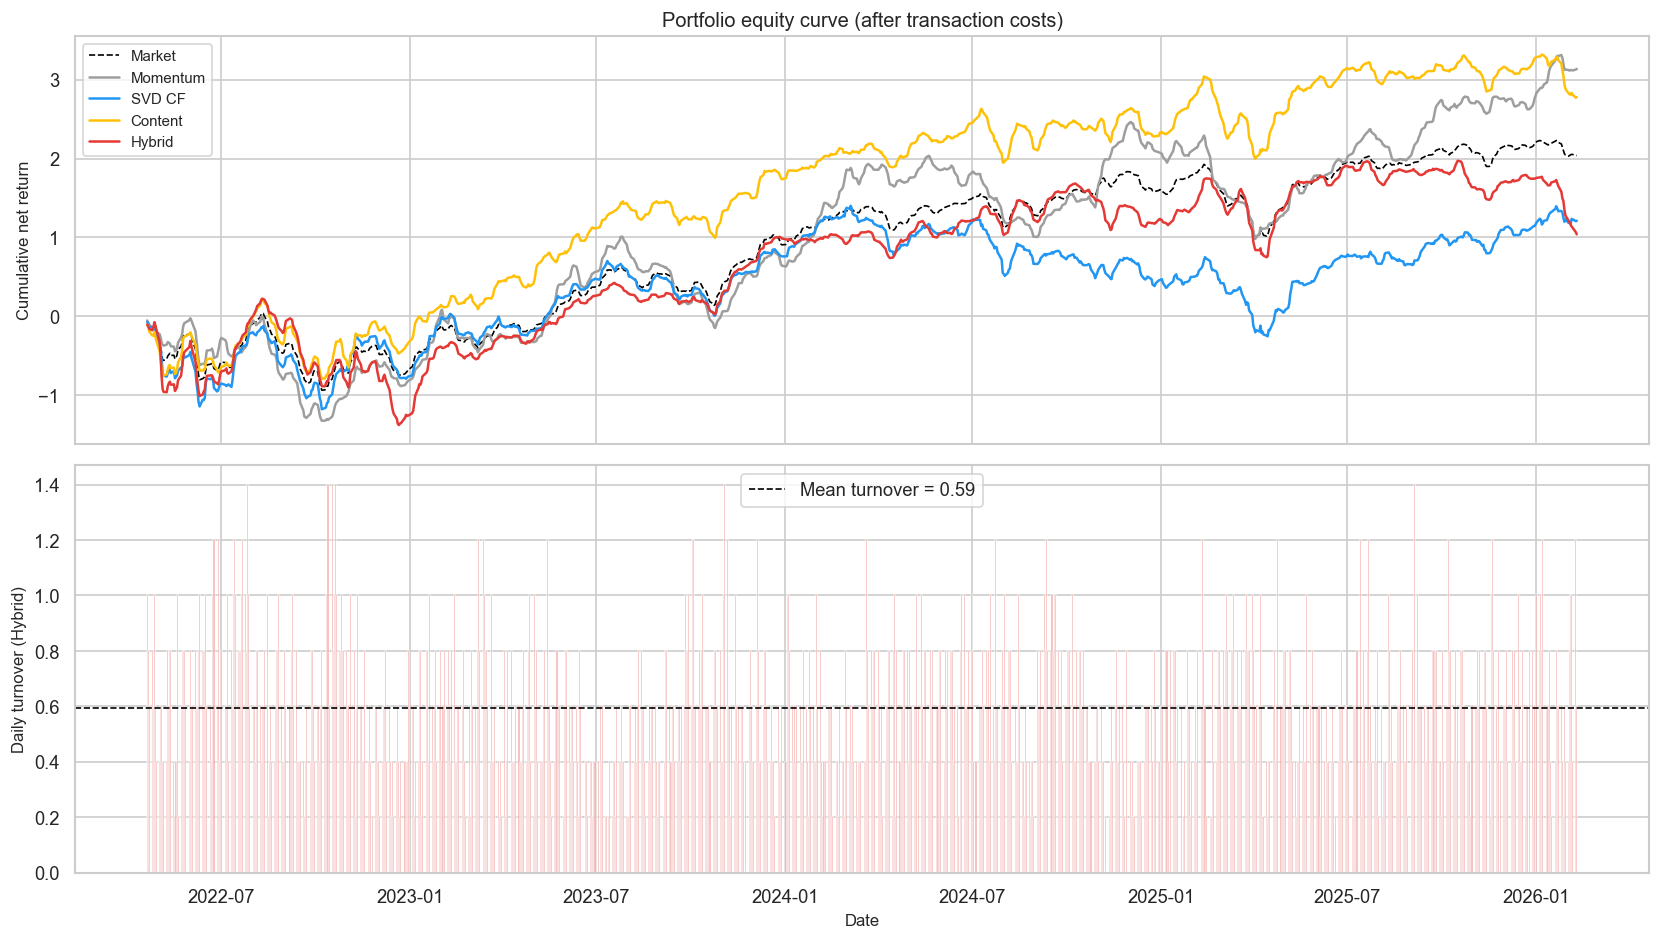


Interpretation:
  - High daily turnover = the portfolio changes a lot each day → higher costs.
  - Turnover of 0.4 means 40% of the 10 stocks are swapped daily on average.
  - If the net return (after costs) still beats the market, the model's
    signal is strong enough to survive realistic trading friction.



In [21]:
# ── Portfolio equity curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
palette = {'Momentum':'#9E9E9E','SVD CF':'#2196F3','Content':'#FFC107','Hybrid':'#E53935'}

# Top: cumulative net return
ax1.plot(mkt_ret.cumsum().index, mkt_ret.cumsum().values,
         color='black', lw=1, linestyle='--', label='Market')
for model_name, sim in sim_results.items():
    cum = sim['Net_Ret'].cumsum()
    ax1.plot(cum.index, cum.values, lw=1.5,
             color=palette[model_name], label=model_name)
ax1.set_ylabel('Cumulative net return')
ax1.set_title('Portfolio equity curve (after transaction costs)')
ax1.legend(fontsize=9)

# Bottom: daily turnover for hybrid (how often recommendations change)
hybrid_sim = sim_results['Hybrid']
ax2.bar(hybrid_sim.index, hybrid_sim['Turnover'],
        color='#E53935', alpha=0.5, width=1)
ax2.axhline(hybrid_sim['Turnover'].mean(), color='black',
            lw=1, linestyle='--',
            label=f'Mean turnover = {hybrid_sim["Turnover"].mean():.2f}')
ax2.set_ylabel('Daily turnover (Hybrid)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

print("""
Interpretation:
  - High daily turnover = the portfolio changes a lot each day → higher costs.
  - Turnover of 0.4 means 40% of the 10 stocks are swapped daily on average.
  - If the net return (after costs) still beats the market, the model's
    signal is strong enough to survive realistic trading friction.
""")

### 4.3 'Why this stock?' — Model Explainability
**Use case:** The model recommends NVDA. Why? Which features drove that recommendation?

In [22]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')
    print('Falling back to feature importance from LightGBM.')

SHAP not installed. Run: pip install shap
Falling back to feature importance from LightGBM.


In [23]:
def explain_recommendation(ticker, date_str, top_features=15):
    """
    Explain why the hybrid model recommended (or didn't recommend) a stock
    on a given date.
    Uses SHAP if available, otherwise a feature-deviation table.
    """
    date      = pd.Timestamp(date_str)
    df_all    = pd.concat([df_val, df_test])
    X_all_aug = np.vstack([X_val_aug, X_test_aug])

    mask = (df_all['Date'] == date) & (df_all['Ticker'] == ticker)
    if mask.sum() == 0:
        print(f'No data for {ticker} on {date_str}')
        return

    row_idx = np.where(mask.values)[0][0]
    X_row   = X_all_aug[row_idx:row_idx + 1]
    score   = float(model_predict(X_row)[0])

    # Rank on this date
    day_mask   = df_all['Date'] == date
    day_scores = model_predict(X_all_aug[day_mask.values])
    rank       = int((day_scores > score).sum()) + 1
    n_tickers  = int(day_mask.sum())

    print(f'\n\u2550\u2550 EXPLANATION: {ticker} on {date_str} \u2550\u2550')
    print(f'  Model score : {score:.4f}')
    print(f'  Rank        : {rank} / {n_tickers}  '
          f'({"\u25b2 RECOMMENDED" if rank <= TOP_N else "\u25bc Not in top-10"})')
    actual  = float(df_all[mask]['Target_Ret_5d'].values[0])
    correct = (score > 0) == (actual > 0)
    print(f'  Actual 5d return : {actual:+.4f} '
          f'({"\u2713 correct direction" if correct else "\u2717 wrong direction"})')

    if SHAP_AVAILABLE:
        # ── SHAP explanation (best option) ────────────────────────────────────
        explainer   = shap.TreeExplainer(lgb_model)
        shap_vals   = explainer.shap_values(X_row)
        shap_series = pd.Series(shap_vals[0], index=AUG_COLS)
        top_shap    = shap_series.abs().nlargest(top_features).index
        fig, ax = plt.subplots(figsize=(10, 5))
        vals   = shap_series[top_shap].sort_values()
        colors = ['#E53935' if v > 0 else '#2196F3' for v in vals]
        ax.barh(vals.index, vals.values, color=colors)
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('SHAP value (impact on model score)')
        ax.set_title(f'Why {ticker} on {date_str}?')
        plt.tight_layout()
        plt.show()
        print('\n  Red = pushed score UP (bullish)  |  Blue = pushed score DOWN (bearish)')

    else:
        # ── Feature deviation table (works for ANY model backend) ─────────────
        # Shows how far each feature is from its training average and which
        # direction that pushes the score.
        # We rank features by |deviation| normalised by training std — this
        # highlights features that are unusually high/low for this stock today.
        print(f'\n  Top-{top_features} most unusual features for {ticker} vs training average:')
        print(f'  (\u25b2 = above average, \u25bc = below average)')
        print()

        X_all_df  = pd.DataFrame(X_all_aug, columns=AUG_COLS)
        train_avg = X_all_df.mean()
        train_std = X_all_df.std().replace(0, 1)   # avoid div-by-zero

        row_series = pd.Series(X_row[0], index=AUG_COLS)
        z_scores   = ((row_series - train_avg) / train_std).abs()
        top_feats  = z_scores.nlargest(top_features).index

        print(f'    {"Feature":<30} {"Value":>8} {"Avg":>8} {"Std":>8} {"Z":>6}  Dir')
        print(f'    {"-"*30} {"-"*8} {"-"*8} {"-"*8} {"-"*6}  ---')
        for feat in top_feats:
            val   = float(row_series[feat])
            avg   = float(train_avg[feat])
            std   = float(train_std[feat])
            z     = (val - avg) / std
            arrow = '\u25b2' if z > 0 else '\u25bc'
            print(f'    {feat:<30} {val:>8.3f} {avg:>8.3f} {std:>8.3f} {z:>6.2f}  {arrow}')


# ── Explain the top-recommended ticker on a sample test date ──────────────────
test_dates  = df_test['Date'].unique()
sample_date = str(test_dates[50].date())

day_mask   = df_test['Date'] == test_dates[50]
day_preds  = model_predict(X_test_aug[day_mask.values])
top_ticker = df_test[day_mask].assign(pred=day_preds).nlargest(1, 'pred')['Ticker'].iloc[0]

print(f'Explaining top recommendation: {top_ticker} on {sample_date}')
explain_recommendation(top_ticker, sample_date)


Explaining top recommendation: TXN on 2022-07-01

══ EXPLANATION: TXN on 2022-07-01 ══
  Model score : 1.5553
  Rank        : 1 / 96  (▲ RECOMMENDED)
  Actual 5d return : +0.0332 (✓ correct direction)

  Top-15 most unusual features for TXN vs training average:
  (▲ = above average, ▼ = below average)

    Feature                           Value      Avg      Std      Z  Dir
    ------------------------------ -------- -------- -------- ------  ---
    SVD_score                        -0.045    0.001    0.017  -2.67  ▼
    Excess_Return                    -2.940    0.005    1.204  -2.45  ▼
    Roll_Mean_21d                    -1.738   -0.021    1.004  -1.71  ▼
    Momentum_score                   -0.161    0.012    0.101  -1.71  ▼
    Momentum_21d                     -1.738   -0.021    1.004  -1.71  ▼
    Volume_Zscore_21d                 1.246    0.059    0.771   1.54  ▲
    Log_Return                       -1.634    0.028    1.130  -1.47  ▼
    Roll_Mean_63d                    -1.483 

### 4.4 Regime Analysis — When Does Each Model Fail?
**Use case:** Understand which market conditions break each model, so you know when to trust it.

In [24]:
# Split the test period into market regimes based on rolling volatility
# HIGH vol regime = market is stressed; LOW vol = calm trending market

mkt_vol = (
    df_test.groupby('Date')['Log_Return']
    .std()
    .rolling(21)
    .mean()
    .rename('Market_Vol')
)
vol_threshold  = mkt_vol.median()
high_vol_dates = mkt_vol[mkt_vol >= vol_threshold].index
low_vol_dates  = mkt_vol[mkt_vol <  vol_threshold].index

print(f'High-vol dates : {len(high_vol_dates)} trading days')
print(f'Low-vol  dates : {len(low_vol_dates)} trading days')

regime_rows = []
for regime, dates in [('High vol', high_vol_dates), ('Low vol', low_vol_dates)]:
    mask = df_test['Date'].isin(dates)
    df_r = df_test[mask]
    for model_name, pred_dict in PREDS.items():
        preds_r = pred_dict['test'][mask.values]
        ic_r, _, _ = mean_ic(df_r, preds_r)
        hr_r       = hit_rate(df_r, preds_r)
        sh_r       = sharpe_ratio(df_r, preds_r)
        regime_rows.append({
            'Regime': regime, 'Model': model_name,
            'IC': ic_r, 'HR': hr_r, 'Sharpe': sh_r
        })

regime_df = pd.DataFrame(regime_rows)
print('\n=== PERFORMANCE BY MARKET REGIME (TEST SET) ===')
print(regime_df.to_string(index=False, float_format='{:.4f}'.format))

High-vol dates : 468 trading days
Low-vol  dates : 468 trading days

=== PERFORMANCE BY MARKET REGIME (TEST SET) ===
  Regime    Model      IC     HR  Sharpe
High vol Momentum  0.0051 0.5244  0.5526
High vol   SVD CF -0.0034 0.5231  0.8048
High vol  Content  0.0291 0.5235  0.9938
High vol   Hybrid  0.0001 0.5203  0.4125
 Low vol Momentum -0.0005 0.5545  3.2160
 Low vol   SVD CF -0.0031 0.5464  2.7288
 Low vol  Content  0.0093 0.5553  3.4915
 Low vol   Hybrid -0.0078 0.5457  2.5459


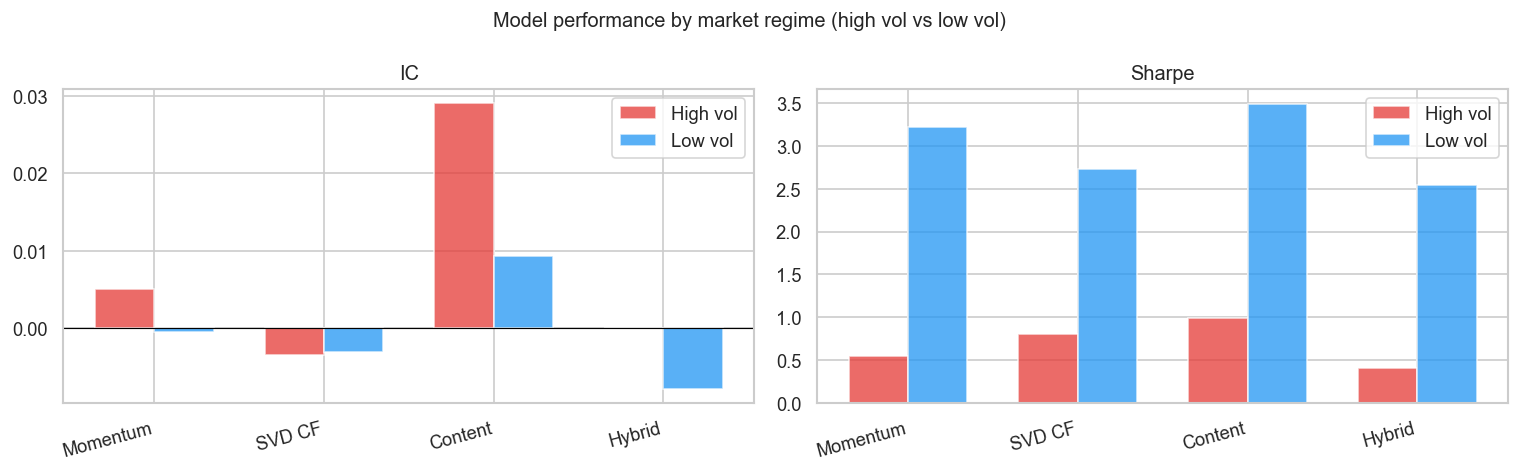


Interpretation:
  - If a model performs much WORSE in high-vol regimes, it learned
    patterns from calm markets that break during stress.
  - Momentum typically FAILS in high-vol (reversals dominate).
  - SVD CF can struggle when a new regime appears that has no
    historical parallel in the training set.
  - A robust hybrid should show smaller performance gap between regimes.
  - Practical implication: you could build a regime detector that
    switches between models based on current volatility level.



In [25]:
# ── Visualise regime performance ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
palette = {'Momentum':'#9E9E9E','SVD CF':'#2196F3','Content':'#FFC107','Hybrid':'#E53935'}
x = np.arange(len(PREDS))
width = 0.35

for ax, metric in zip(axes, ['IC', 'Sharpe']):
    for i, (regime, offset) in enumerate([('High vol', -width/2), ('Low vol', width/2)]):
        vals = regime_df[regime_df['Regime'] == regime].set_index('Model')[metric]
        bars = ax.bar(x + offset, vals.values, width,
                      label=regime,
                      color=['#E53935','#2196F3'][i], alpha=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(list(PREDS.keys()), rotation=15, ha='right')
    ax.set_title(metric)
    ax.axhline(0, color='black', lw=0.7)
    ax.legend()

plt.suptitle('Model performance by market regime (high vol vs low vol)', fontsize=12)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - If a model performs much WORSE in high-vol regimes, it learned
    patterns from calm markets that break during stress.
  - Momentum typically FAILS in high-vol (reversals dominate).
  - SVD CF can struggle when a new regime appears that has no
    historical parallel in the training set.
  - A robust hybrid should show smaller performance gap between regimes.
  - Practical implication: you could build a regime detector that
    switches between models based on current volatility level.
""")

---
## 5. Final Summary Table

In [26]:
# ── Consolidated evaluation summary ──────────────────────────────────────────
test_res = results_df[results_df['Split'] == 'Test'].set_index('Model')

print('='*80)
print('FINAL EVALUATION SUMMARY — TEST SET')
print('='*80)
print(test_res[['RMSE','MAE','IC','ICIR',f'HR@{TOP_N}',f'NDCG@{TOP_N}','Sharpe']]
      .to_string(float_format='{:.4f}'.format))
print()
print('Metric guide:')
print('  RMSE / MAE    — lower is better  (regression accuracy)')
print('  IC            — higher is better (rank correlation, > 0.05 = useful)')
print('  ICIR          — IC / IC_std      (consistency; > 0.5 is good)')
print(f'  HR@{TOP_N}        — higher is better (> 0.55 beats random)')
print(f'  NDCG@{TOP_N}      — higher is better (perfect ranking = 1.0)')
print('  Sharpe        — higher is better (> 1.0 good, > 2.0 excellent)')
print()
best = test_res['Sharpe'].idxmax()
print(f'  Best model by Sharpe ratio: {best}')
best = test_res['IC'].idxmax()
print(f'  Best model by IC          : {best}')

# Save results
results_df.to_csv(f'{MODEL_PATH}/final_evaluation.csv', index=False)
print(f'\nResults saved to {MODEL_PATH}/final_evaluation.csv')

FINAL EVALUATION SUMMARY — TEST SET
           RMSE    MAE      IC    ICIR  HR@10  NDCG@10  Sharpe
Model                                                         
Momentum 0.1173 0.0858  0.0041  0.0182 0.5348   0.5286  1.5420
SVD CF   0.0549 0.0397 -0.0031 -0.0169 0.5302   0.5273  1.2090
Content  0.0521 0.0375  0.0179  0.0910 0.5350   0.5330  1.5967
Hybrid   0.9334 0.7749 -0.0051 -0.0216 0.5290   0.5201  0.6962

Metric guide:
  RMSE / MAE    — lower is better  (regression accuracy)
  IC            — higher is better (rank correlation, > 0.05 = useful)
  ICIR          — IC / IC_std      (consistency; > 0.5 is good)
  HR@10        — higher is better (> 0.55 beats random)
  NDCG@10      — higher is better (perfect ranking = 1.0)
  Sharpe        — higher is better (> 1.0 good, > 2.0 excellent)

  Best model by Sharpe ratio: Content
  Best model by IC          : Content

Results saved to ./models/final_evaluation.csv
